# Week 10 - Multi-rate Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

def spectrum(x, fs, NFFT=-1):
    if NFFT == -1:
        NFFT = len(x)
    X = np.fft.fft(x, NFFT)
    N = len(X)
    X = X[:N//2]
    mag = np.abs(X)*2/N
    freq = np.arange( len(mag) ) * fs / N
    return freq, mag

In [2]:
# time axis of 10 and 5 Hz
fs = 10
t = time_axis(fs, 1)
print(t)
fs = 5
t = time_axis(fs, 1)
print(t)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.  0.2 0.4 0.6 0.8]


In [3]:
# downsampling from 10 Hz to 5 Hz
fs = 10
t = time_axis(fs, 1)
fs_new = 5
M = int(fs/fs_new)
print(fs_new)
print(t[::M])

5
[0.  0.2 0.4 0.6 0.8]


## Example : Downsampling

### do nothing

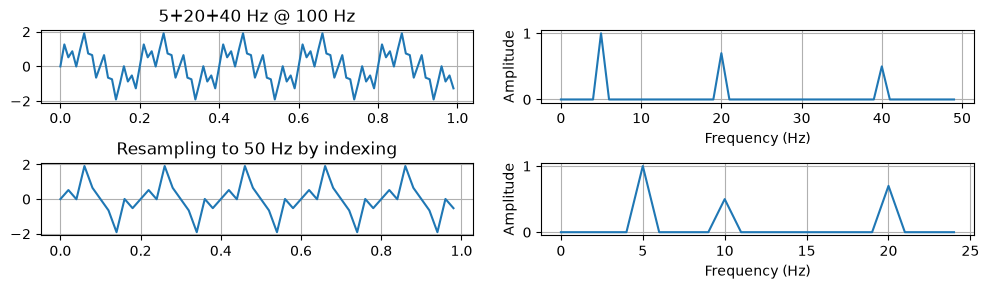

In [4]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 50
M = int(fs/fs_new)
t_new = t[::M]
x_new = x[::M]
freq, mag = spectrum(x_new, fs_new)
plt.subplot(2,2,3)
plt.plot(t_new, x_new); plt.grid(); plt.title("Resampling to 50 Hz by indexing")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

### filter first

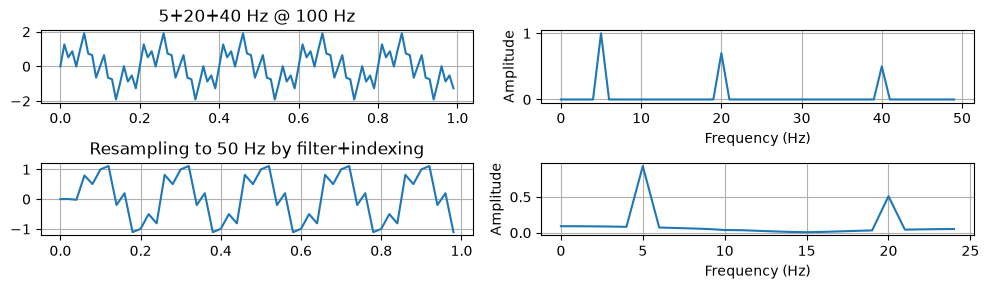

In [5]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

b = signal.firwin(numtaps=11, cutoff=25, fs=fs)
a = [1]
x_low = signal.lfilter(b, a, x)
fs_new = 50
M = int(fs/fs_new)
t_new = t[::M]
x_new = x_low[::M]
freq, mag = spectrum(x_new, fs_new)
plt.subplot(2,2,3)
plt.plot(t_new, x_new); plt.grid(); plt.title("Resampling to 50 Hz by filter+indexing")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Exercise 1

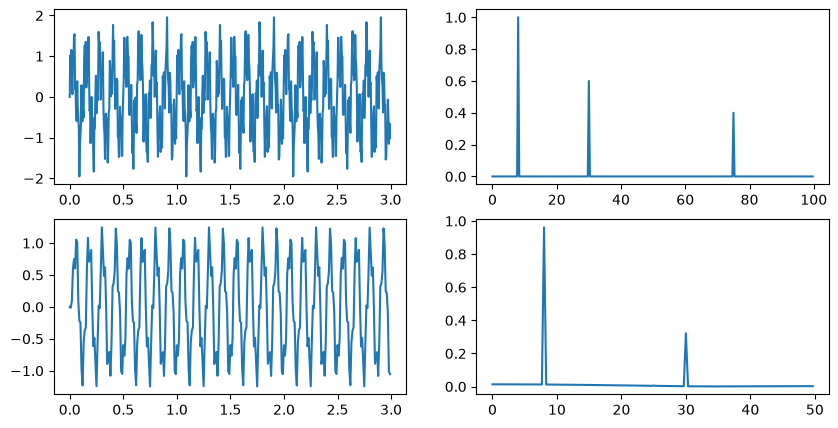

In [10]:
# Ex1: anti-alias filter, then drop
# สัญญาณใหม่ 8 + 30 + 75 Hz ที่ fs = 200 Hz ยาว 3 วินาที ต้องการลดเหลือ 100 Hz
fs = 200
t = time_axis(fs, 3)
x = generate_sine(8, t, 1) + generate_sine(30, t, 0.6) + generate_sine(75, t, 0.4)
plt.figure(figsize = (10, 5))
plt.subplot(2, 2, 1); plt.plot(t, x)
freq, mag = spectrum(x, fs)
plt.subplot(2, 2, 2); plt.plot(freq, mag)

b = signal.firwin(numtaps=11, cutoff=31, fs=fs)
a = [1]
x_low = signal.lfilter(b, a, x)
fs_new = 100
M = int(fs/fs_new)
t_new = t[::M]
x_new = x_low[::M]
plt.subplot(2,2,3); plt.plot(t_new, x_new)

freq, mag = spectrum(x_new, fs_new)
plt.subplot(2,2,4); plt.plot(freq, mag)


### Decimate

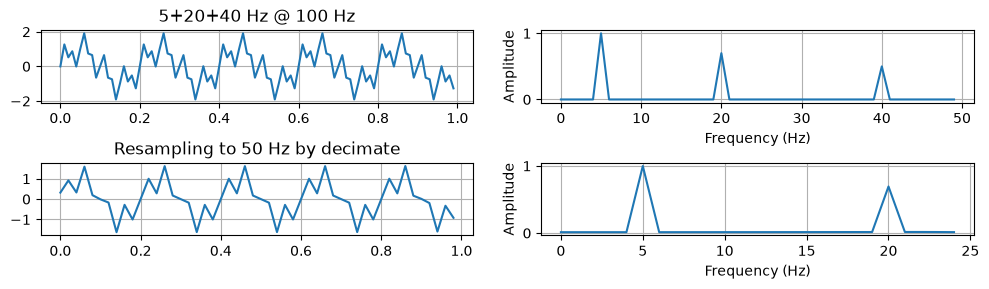

In [13]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 50
M = int(fs/fs_new)
x_new = signal.decimate(x, M, ftype='fir', zero_phase=True)
t_new = np.arange(len(x_new)) / fs_new
freq, mag = spectrum(x_new, fs_new)
plt.subplot(2,2,3)
plt.plot(t_new, x_new); plt.grid(); plt.title("Resampling to 50 Hz by decimate")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

### resample_poly

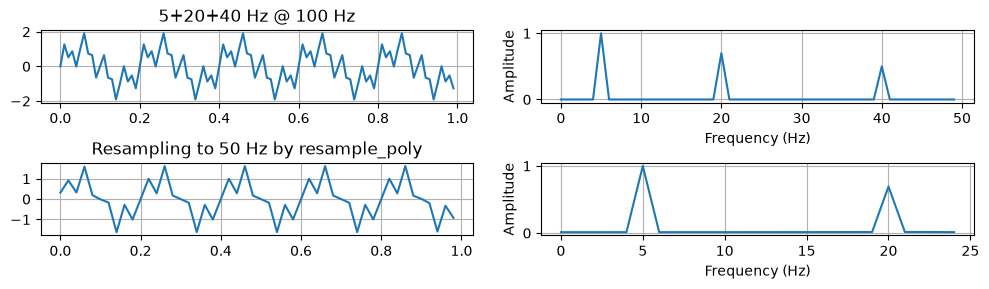

In [14]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 50
x_down = signal.resample_poly(x, 1, 2)
t_down = np.arange(len(x_down)) / fs_new
freq, mag = spectrum(x_down, fs_new)
plt.subplot(2,2,3)
plt.plot(t_down, x_down); plt.grid(); plt.title("Resampling to 50 Hz by resample_poly")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Exercise 2

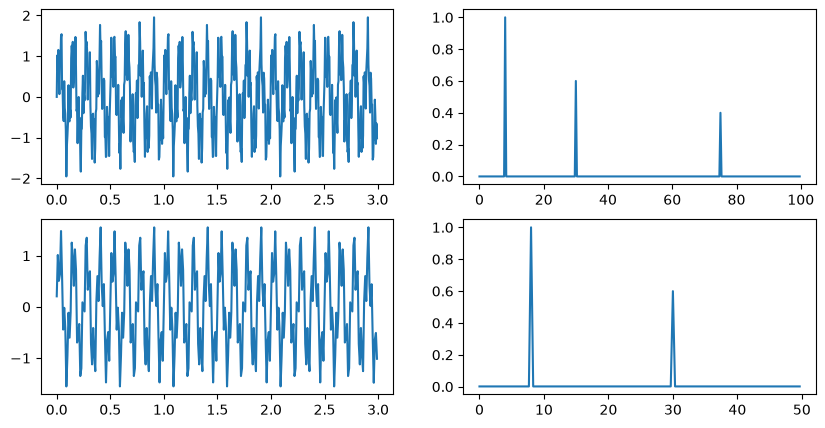

In [15]:
# Ex2: resample_poly
# สัญญาณเดิมของข้อ 1 คือ 8 + 30 + 75 Hz ที่ fs = 200 Hz ต้องการลดเหลือ 100 Hz

fs = 200
t = time_axis(fs, 3)
x = generate_sine(8, t, 1) + generate_sine(30, t, 0.6) + generate_sine(75, t, 0.4)
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1); plt.plot(t, x)
freq, mag = spectrum(x, fs)
plt.subplot(2, 2, 2,); plt.plot(freq, mag)
a = 1; b = 2
fs_new = a/b * fs
x_down = signal.resample_poly(x, a, b)
t_down = np.arange(len(x_down)) / fs_new
plt.subplot(2, 2, 3); plt.plot(t_down, x_down)
freq, mag = spectrum(x_down, fs_new)
plt.subplot(2, 2, 4);  plt.plot(freq, mag)


## Exercise 3 : the real recording

duration= 35.666


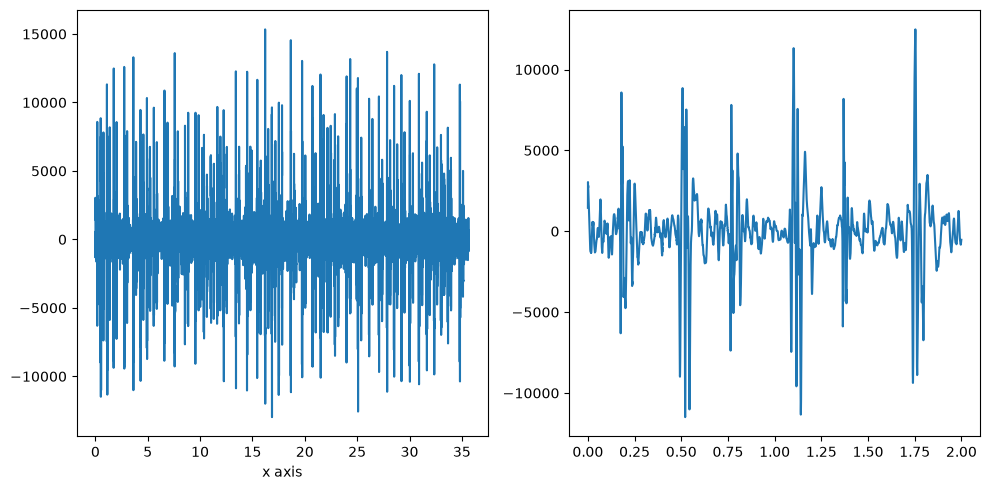

In [21]:
# Ex3: resample_poly กับเสียงหัวใจจริง
# เสียงหัวใจจากหูฟังแพทย์ บันทึกที่ 2000 Hz จะลดเหลือ 100 Hz
# ก่อนรัน จงตอบ: กำลังงานที่อยู่เหนือ 50 Hz คิดเป็นกี่เปอร์เซ็นต์ และมันจะหายไปไหน
from scipy.io import wavfile
fs_h, h = wavfile.read("heart_sound_normal1.wav")
print("duration=", len(h)/fs_h)
t_h  = np.arange(len(h)) /fs_h
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.plot(t_h, h); plt.xlabel("x axis");
duration = 2
h = h[:duration*fs_h]
t_h  = np.arange(len(h)) /fs_h
plt.subplot(1, 2, 2); plt.plot(t_h, h)
plt.tight_layout()

## Upsampling

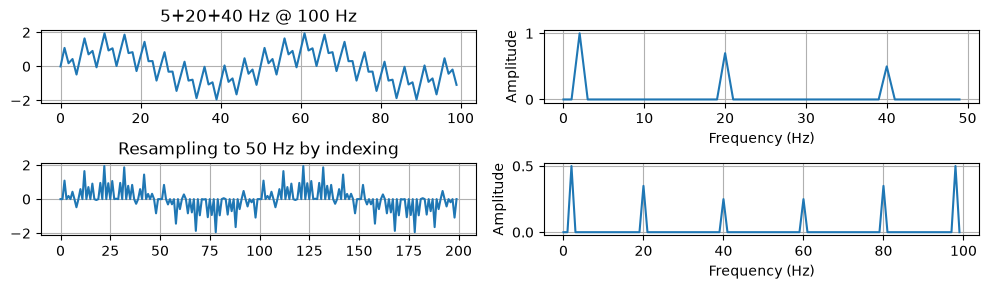

In [22]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(2, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 200
L = int(fs_new/fs)
x_up = np.zeros( len(t)*L )
x_up[::L] = x

freq, mag = spectrum(x_up, fs_new)
plt.subplot(2,2,3)
plt.plot(x_up); plt.grid(); plt.title("Resampling to 50 Hz by indexing")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

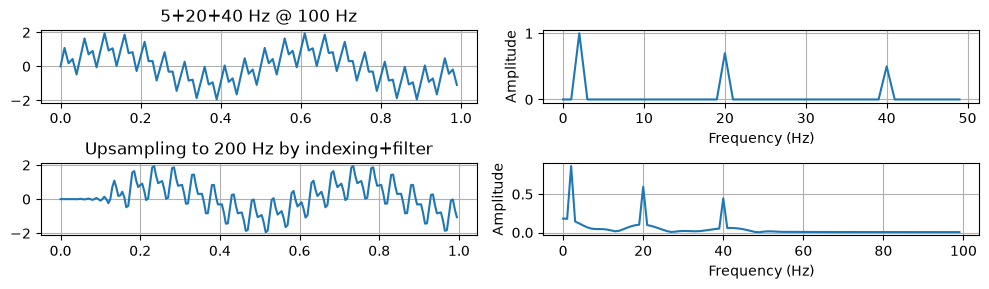

In [23]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(2, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 200
L = int(fs_new/fs)
x_up = np.zeros( len(t)*L )
x_up[::L] = x
b = signal.firwin(numtaps=51, cutoff=fs/2, fs=fs_new)
a = [1]
x_up = signal.lfilter(b, a, x_up)
x_up *= L
t_up = np.arange(len(x_up)) / fs_new
freq, mag = spectrum(x_up, fs_new)
plt.subplot(2,2,3)
plt.plot(t_up, x_up); plt.grid(); plt.title("Upsampling to 200 Hz by indexing+filter")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Exercise 4

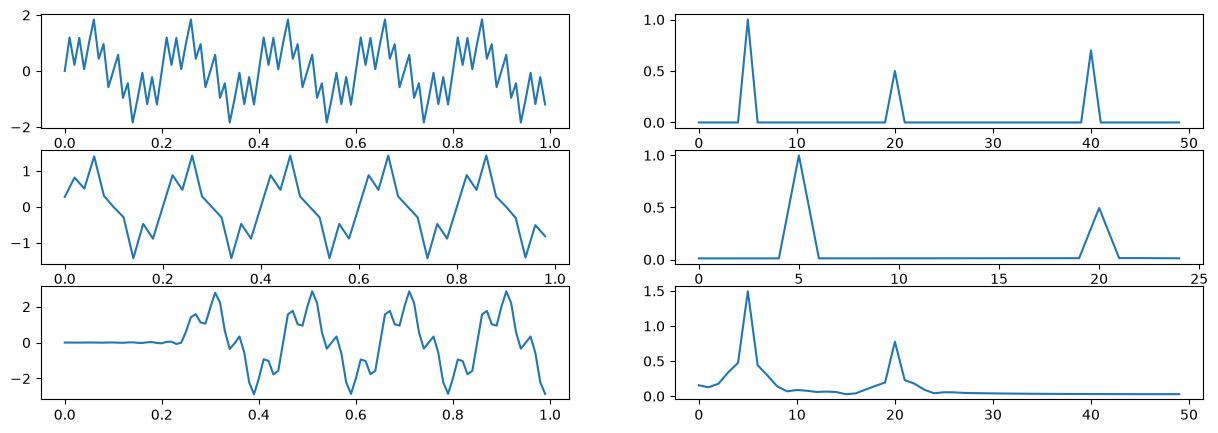

In [36]:
# Ex4: insert, filter, then multiply by L
# สัญญาณเดิมของหัวข้อที่แล้ว 5 + 20 + 40 Hz ที่ fs = 100 Hz ลดเหลือ 50 Hz
# จะได้สัญญาณที่มี 5 กับ 20 Hz ส่วน 40 Hz ถูกกรองทิ้งไปแล้ว จากนั้นยกกลับขึ้นไป 100 Hz
fs = 100
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.5) + generate_sine(40, t, 0.7)
plt.figure(figsize=(15, 5))
plt.subplot(3, 2, 1); plt.plot(t, x)
freq, mag = spectrum(x, fs)
plt.subplot(3, 2, 2); plt.plot(freq, mag)
a = 1; b = 2
fs_down = a/b * fs
x_down = signal.resample_poly(x, a, b)
t_down = np.arange(len(x_down)) / fs_down
plt.subplot(3, 2, 3); plt.plot(t_down, x_down)
freq, mag = spectrum(x_down, fs_down)
plt.subplot(3, 2, 4); plt.plot(freq, mag)

fs_up = 100
L = int(fs_up/fs_down)
x_up = signal.resample_poly(x_down, L, 1)
b = signal.firwin(numtaps=51, cutoff=fs_down/2, fs=fs_up)
a = [1]
x_up = signal.lfilter(b, a, x_up)
x_up *= L
t_up = np.arange(len(x_up)) / fs_up
freq, mag = spectrum(x_up, fs_up)
plt.subplot(3, 2, 5); plt.plot(t_up, x_up)
plt.subplot(3, 2, 6); plt.plot(freq, mag)

### Resample_poly

In [ ]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(2, t, 1) + generate_sine(20, t, 0.7) + generate_sine(40, t, 0.5)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 200
L = int(fs_new/fs)
x_up = signal.resample_poly(x, 2, 1)
t_up = np.arange(len(x_up)) / fs_new
freq, mag = spectrum(x_up, fs_new)
plt.subplot(2,2,3)
plt.plot(t_up, x_up); plt.grid(); plt.title("Upsampling to 200 Hz by resample_poly")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Exercise 5

In [37]:
# Ex5: resample_poly ขาขึ้น แล้วเทียบกับวิธีทำเองของข้อ 4
# resample_poly(x, up, down) ใช้ได้ทั้งสองทาง ขาขึ้นให้ up = L และ down = 1

#done in the previous exercise

## Exercise 6

duration= 35.666
100.0


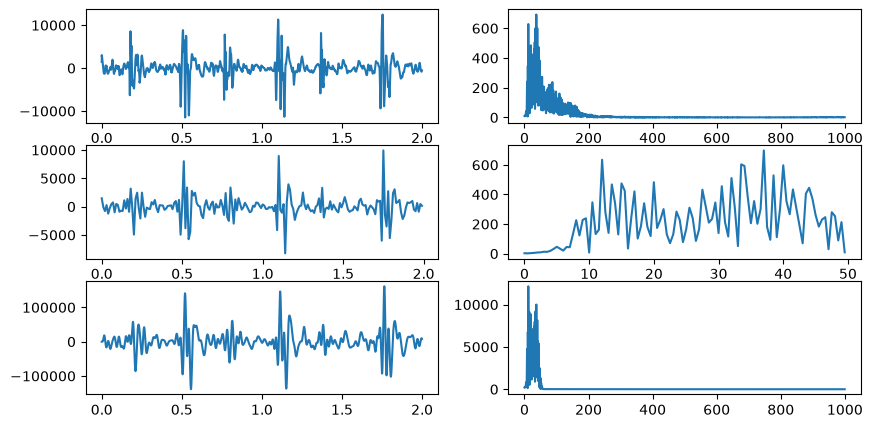

In [39]:
# Ex6: ข้อ 3 เราโหลด "heart_sound_normal1.wav" ที่ 2000 Hz แล้ว downsampling ไปที่ 100 Hz
# ครั้งนี้ เราจะทำกลับ เอาเสียงหัวใจ 100 Hz ของข้อ 3 กลับขึ้นไปที่ 2000 Hz

fs, x = wavfile.read("heart_sound_normal1.wav")
print("duration=", len(x)/fs)
t  = np.arange(len(x)) /fs
plt.figure(figsize=(10, 5))
duration = 2
x = x[:duration*fs]
t  = np.arange(len(h)) /fs
plt.subplot(3, 2, 1); plt.plot(t, x)
freq, mag = spectrum(x, fs)
plt.subplot(3, 2, 2); plt.plot(freq, mag)

a = 1; b = 20
fs_down = a/b * fs
print(fs_down)
x_down = signal.resample_poly(x, a, b)
t_down = np.arange(len(x_down)) / fs_down
plt.subplot(3, 2, 3); plt.plot(t_down, x_down)
freq, mag = spectrum(x_down, fs_down)
plt.subplot(3, 2, 4); plt.plot(freq, mag)

fs_up = 2000
L = int(fs_up/fs_down)
x_up = signal.resample_poly(x_down, L, 1)
b = signal.firwin(numtaps=51, cutoff=fs_down/2, fs=fs_up)
a = [1]
x_up = signal.lfilter(b, a, x_up)
x_up *= L
t_up = np.arange(len(x_up)) / fs_up
freq, mag = spectrum(x_up, fs_up)
plt.subplot(3, 2, 5); plt.plot(t_up, x_up)
plt.subplot(3, 2, 6); plt.plot(freq, mag)


## Rational L/M

In [40]:
# อัตราส่วนของสองอัตราชักตัวอย่าง เขียนเป็นเศษส่วนอย่างต่ำ
from fractions import Fraction

fs_up = 2000
fs_down = 44100

ratio = Fraction(fs_up, fs_down)
L_lm, M_lm = ratio.numerator, ratio.denominator
print(L_lm, M_lm)

20 441


In [41]:
fs_up = 44100
fs_down = 2000

ratio = Fraction(fs_up, fs_down)
L_lm, M_lm = ratio.numerator, ratio.denominator
print(L_lm, M_lm)

441 20


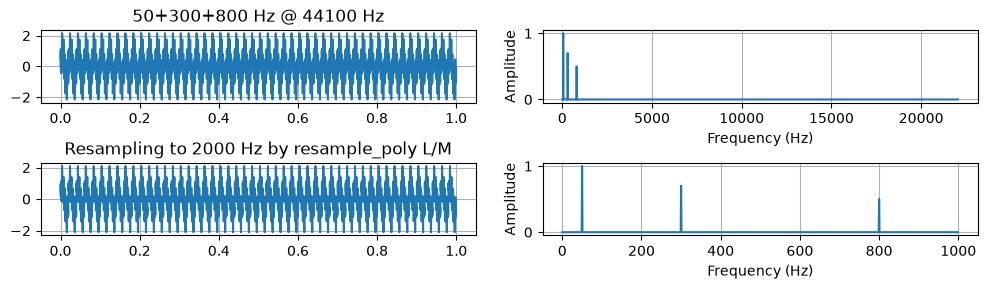

In [42]:
fs_old = 44100
t = time_axis(fs_old, 1)
x = generate_sine(50, t, 1) + generate_sine(300, t, 0.7) + generate_sine(800, t, 0.5)
freq, mag = spectrum(x, fs_old)

plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("50+300+800 Hz @ 44100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")

fs_new = 2000
ratio = Fraction(fs_new, fs_old)
L_lm, M_lm = ratio.numerator, ratio.denominator

x_resample = signal.resample_poly(x, L_lm, M_lm)
t_resample = np.arange(len(x_resample)) / fs_new
freq, mag = spectrum(x_resample, fs_new)

plt.subplot(2,2,3)
plt.plot(t_resample, x_resample); plt.grid(); plt.title("Resampling to 2000 Hz by resample_poly L/M")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Exercise 7

5 3


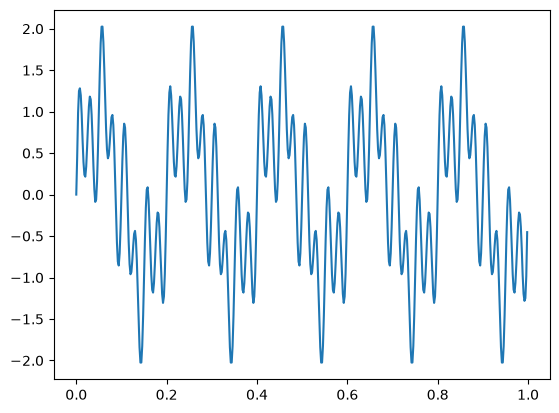

In [48]:
# Ex7: rational L/M กับสัญญาณหลายความถี่
# สัญญาณ 5 + 20 + 40 Hz แบบเดียวกับข้อ 4 แต่คราวนี้บันทึกมาที่ fs = 300 Hz
# ต้องการเปลี่ยนไปที่ fs = 500 Hz ซึ่งไม่ใช่จำนวนเต็มเท่าของ 300
fs = 300
t = time_axis(fs, 1)
x = generate_sine(5, t, 1) + generate_sine(20, t, 0.5) + generate_sine(40, t, 0.7)

fs_up = 500
fs_down= 300
ratio = Fraction(fs_up, fs_down)
L, M = ratio.numerator, ratio.denominator
print(L, M)
x_new = signal.resample_poly(x, L, M)
t_new = np.arange(len(x_new))/fs_up
plt.plot(t_new, x_new)

## Exercise 8

21609 1000
min, max: -12990.164556675136 15356.671153514526 float64


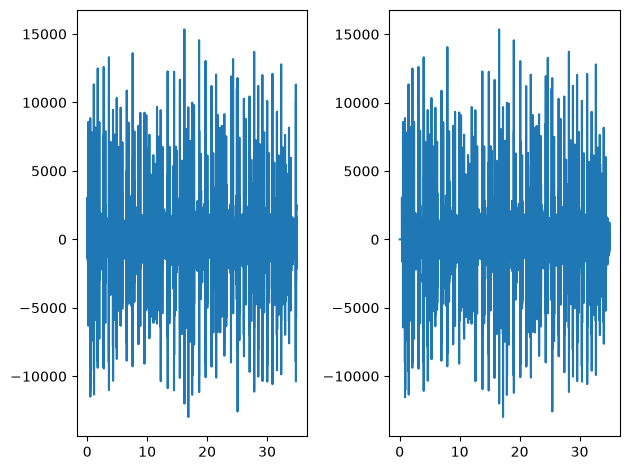

In [64]:
# Ex8.1 : synthesize a second recording of the same heart and WRITE it as a wav  (SYNTHETIC)
# เราจะสังเคราะห์ "heart_sound_normal1.wav" (2000 Hz) ให้เป็นสัญญาณที่ไมโครโฟนตัวที่สองบันทึกที่ 44100 Hz
# โดยกดบันทึกช้ากว่า 0.37 วินาที ยาว 30 วินาที และนาฬิกาของเครื่องเดินช้ากว่าที่ header บอก 0.2 % (44011.8 Hz จริง)
# แล้วบันทึกเป็นไฟล์ เพื่อจำลองว่าเราได้ไฟล์นั้นมาจริง ๆ  ชื่อเดิม + "_44100"

fs, x = wavfile.read("heart_sound_normal1.wav")
duration = 35
x = x[:duration*fs]
t  = np.arange(len(x)) /fs
plt.subplot(1, 2, 1); plt.plot(t, x)

fs_new = 44100*0.98
# ratio = Fraction(fs_new, fs)
ratio = Fraction(fs_new/fs).limit_denominator(10000)
L, M = ratio.numerator, ratio.denominator
print(L, M)
x_new= signal.resample_poly(x, L, M)
t_new= np.arange(len(x_new)) / fs_new
# plt.subplot(1, 2, 2); plt.plot(t_new, x_new)



#add delay
delay = 0.37
delay_sample = int(fs_new*delay)
x_delay = np.zeros(len(x_new))
x_delay[delay_sample:] = x_new[:-delay_sample]
print("min, max:", min(x_delay), max(x_delay), x_delay.dtype)

wavfile.write("heart_sound_normal1_44100.wav", 44100, x_delay)

plt.subplot(1, 2, 2); plt.plot(t_new, x_delay)
plt.tight_layout()

2000
2000


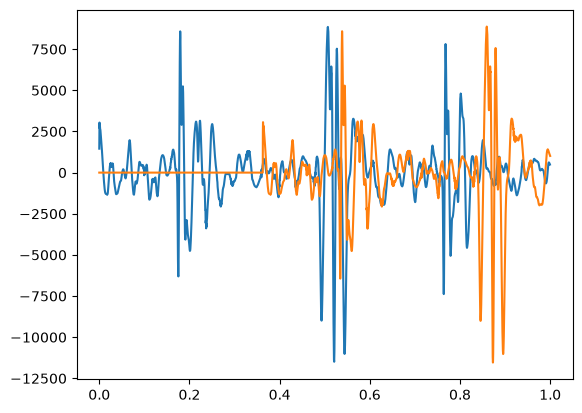

In [69]:
duration = 1
fs1, x1 = wavfile.read("heart_sound_normal1.wav")
x1 = x1[:fs1*duration]
t1 = np.arange(len(x1)) / fs1
print(fs)
fs2, x2 = wavfile.read("heart_sound_normal1_44100.wav")
x2 = x2[:fs2*duration]
t2 = np.arange(len(x2)) / fs2
print(fs)
plt.plot(t1, x1)
plt.plot(t2, x2)

In [ ]:
# Ex8.2 : two recordings of the same heart, one axis
# A คือหูฟังแพทย์ 2000 Hz (ของจริง)  B คือไฟล์ที่เพิ่งเขียน heart_sound_normal1_44100.wav
# เริ่มจากอ่านไฟล์ สำรวจ fs และจำนวนจุด แล้ว plot  จากนั้นกำหนด target fs = 2000 Hz หา L/M อย่างต่ำ แล้ว resample


## Alignment : offset

In [ ]:
# example
fs = 100
t = time_axis(fs, 3)
x1 = generate_sine(f=1, t=t, A=1, p=0)
delay = 10
x2 = np.zeros(len(x1))
x2[delay:] = x1[:-delay]

plt.plot(t, x1)
plt.plot(t, x2)
plt.grid()
plt.show()

In [ ]:
x1 = (x1 - np.mean(x1))/np.std(x1)
x2 = (x2 - np.mean(x2))/np.std(x2)

corr = signal.correlate(x1, x2, mode="full")
lags = signal.correlation_lags(len(x1), len(x2), mode="full")

plt.plot(lags, corr)
plt.grid()

d = lags[np.argmax(corr)]
print(d)

In [ ]:
def correlation_offset(x1, x2):
    x1 = (x1 - np.mean(x1))/np.std(x1)
    x2 = (x2 - np.mean(x2))/np.std(x2)
    
    corr = signal.correlate(x1, x2, mode="full")
    lags = signal.correlation_lags(len(x1), len(x2), mode="full")

    d = lags[np.argmax(corr)]
    return corr, lags, d

In [ ]:
y = np.zeros(len(x2))
if d > 0: # shift right
    y[d:] = x2[:-d]
elif d < 0: # shift left
    y[:d] = x2[-d:]

plt.plot(t, x1)
plt.plot(t, y)
plt.legend(["x1", "y"])
plt.grid()
plt.show()

In [ ]:
if d < 0:
    x1_aligned = x1[:d]
    t_aligned = t[:d]
    x2_aligned = x2[-d:]
elif d > 0:
    x1_aligned = x1[d:]
    t_aligned = t[d:]
    x2_aligned = x2[:-d]
    
plt.plot(t_aligned, x1_aligned)
plt.plot(t_aligned, x2_aligned)
plt.legend(["x1", "x2"])
plt.grid()
plt.show()

In [ ]:
def shift_signal(x1, x2, t, d):
    if d < 0:
        x1_aligned = x1[:d]
        t_aligned = t[:d]
        x2_aligned = x2[-d:]
    elif d > 0:
        x1_aligned = x1[d:]
        t_aligned = t[d:]
        x2_aligned = x2[:-d]
    return x1_aligned, x2_aligned, t_aligned

## Exercise 9

In [ ]:
# Ex9.1 : สร้างสัญญาณ 5 Hz ที่ 100 Hz, delay ไป 20 samples, ตรวจ offset ด้วย cross-correlation, เลื่อนสัญญาณให้ตรงกัน และ crop



In [ ]:
# Ex9.2 : อ่าน heart sound และปรับ offset ให้ตรงกัน โดยทำพร้อมกันทั้งสัญญาณ
# A = heart_sound_normal1.wav (2000 Hz)   B_new = heart_sound_normal1_44100.wav ที่ resample ลงมา 2000 Hz แล้ว (Ex 8.2)


In [ ]:
# Ex9.3 เหมือนข้อ 9.2 แต่เลือกปรับ 5 วินาทีแรก



In [ ]:
# Ex9.4 Framing : แบ่งเป็นหน้าต่าง หา d ของแต่ละหน้าต่าง แล้วเลื่อนทีละหน้าต่าง  เทียบกับข้อ 9.2



## Alignment : linear drift

In [ ]:
# example
fs1 = 100
t1 = time_axis(fs1, 5)
x1 = generate_sine(f=1, t=t1, A=1, p=0)
fs2 = 99.9
t2 = time_axis(fs2, 5)
x2 = generate_sine(f=1, t=t2, A=1, p=0)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t1, x1)
plt.plot(t2, x2)
plt.legend(["@100Hz", "@99.9Hz"])
plt.grid()

plt.subplot(1,2,2)
plt.plot(t2-t1)
plt.legend(["Time err"])
plt.grid()
plt.show()

In [ ]:
# example : บันทึกนานขึ้นเป็น 60 วินาที  ความต่างที่ 5 วินาทีมองไม่เห็น จะโตจนเห็นชัด
fs1 = 100
t1 = time_axis(fs1, 60)
x1 = generate_sine(f=1, t=t1, A=1, p=0)
fs2 = 99.9
t2 = time_axis(fs2, 60)
x2 = generate_sine(f=1, t=t2, A=1, p=0)
n = min(len(x1), len(x2))
print("samples in 60 s :", len(x1), "at 100 Hz   vs", len(x2), "at 99.9 Hz")
print("time error at the last common sample :", round(t2[n-1] - t1[n-1], 3), "s")
rms_index = np.sqrt(np.mean((x1[:n] - x2[:n])**2))
print("rms of x1 - x2 paired by index :", round(rms_index, 4))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t1, x1); plt.plot(t2, x2); plt.xlim(55, 60)
plt.legend(["@100Hz", "@99.9Hz"]); plt.grid(); plt.title("55-60 s")
plt.subplot(1, 2, 2)
plt.plot(t2[:n] - t1[:n]); plt.legend(["Time err"]); plt.grid()
plt.tight_layout()
plt.show()
# ที่ 5 วินาที คลาด 0.005 วินาที  ที่ 60 วินาที คลาด 0.06 วินาที = 6 samples  รูปซ้ายเห็นสองเส้นแยกกันแล้ว


### Sliding Cross-Correlation

In [ ]:
A = np.arange(20)
print(A)
window_size = 5
A_window = np.lib.stride_tricks.sliding_window_view(A, window_size)
print(A_window)
window_step = 5
A_window = A_window[::window_step]
print(A_window)

In [ ]:
duration = 1
fs = 100
window_size = duration*fs
x1_window = np.lib.stride_tricks.sliding_window_view(x1, window_size)
x2_window = np.lib.stride_tricks.sliding_window_view(x2, window_size)

window_step = window_size
x1_window = x1_window[::window_step]
x2_window = x2_window[::window_step]
print(len(x1_window), len(x2_window))

In [ ]:
_, _, d = correlation_offset(x1_window[0], x2_window[0])
print(d)
out = [correlation_offset(x1_window[i], x2_window[i]) for i in range(len(x2_window))]
d = [int(out[i][2]) for i in range(len(out))]
print(d)
plt.plot(d, 'o')

In [ ]:
print(len(x1), len(x2))
signal_duration = 60
print(len(x1)/signal_duration, len(x2)/signal_duration)

In [ ]:
# fix : drift คือระยะห่างระหว่าง sample ผิด  แก้ด้วยการ resample จากอัตราจริงไปอัตราที่ header บอก = Rational L/M อีกครั้ง
ratio = Fraction(fs1 / fs2).limit_denominator(1000)       # 100 / 99.9 = 1000 / 999
print("L", ratio.numerator, "M", ratio.denominator)

x2_fixed = signal.resample_poly(x2, ratio.numerator, ratio.denominator)
n = min(len(x1), len(x2_fixed))
rms_poly = np.sqrt(np.mean((x1[:n] - x2_fixed[:n])**2))
print("resample_poly :", len(x2), "->", len(x2_fixed), "samples   rms of x1 - x2_fixed :", round(rms_poly, 4))

# # ทางเลือกที่สอง : แกนเวลาจริงของ x2 คือ n / 99.9  แล้ว np.interp ขอค่า ณ เวลาของ x1 (common time grid)
# t2_true = np.arange(len(x2)) / fs2
# keep = t1 <= t2_true[-1]
# x2_interp = np.interp(t1[keep], t2_true, x2)
# rms_interp = np.sqrt(np.mean((x1[keep] - x2_interp)**2))
# print("np.interp on the true axis :", round(rms_interp, 4))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t1, x1); 
plt.plot(t1[:n], x2_fixed[:n]); 
plt.xlim(55, 60)
plt.legend(["@100Hz", "@99.9Hz resample_poly 1000/999"]); plt.grid(); plt.title("55-60 s, after the rate fix")
plt.subplot(1, 2, 2)
plt.plot(t1[:n], x1[:n] - x2_fixed[:n]); plt.legend(["x1 - x2_fixed"]); plt.grid()
plt.tight_layout()
plt.show()


## Exercise 10

In [ ]:
# Ex10.1 : สัญญาณ 5 Hz ยาว 20 วินาที  ชุดแรก fs=100 Hz  ชุดสอง header fs=100 Hz fsจริง=99.7 Hz และกดอัดช้า 0.04 วินาที
# 1. สร้างสัญญาณทั้ง 2 แล้ว plot เทียบ เพื่อสังเกตุความแตกต่างด้วยตา
# 2. resample_poly ชุดสองด้วย L/M จาก 100 / 99.7 (แก้ linear drift)
# 3. หา offset ด้วย cross-correlation เลื่อนและ crop (แก้ offset)
# 4. plot และ รายงาน rms แต่ละขั้น



In [ ]:
# Ex10.2 :
# อ่าน heart sound แก้ linear drift และ ปรับ offset ให้ตรงกัน
# A = heart_sound_normal1.wav (2000 Hz)   B_new = heart_sound_normal1_44100.wav ที่ resample ลงมา 2000 Hz แล้ว (Ex 8.2)
# 1. ตรวจสอบ fs ของแต่ละสัญญาณ, หาหลักฐานว่าเกิด linear drift
# 2. ถ้าเกิด แก้ด้วย resampling ไปที่ fs เดียวกัน
# 3. หาหลักฐานว่าเกิด offset
# 4. ถ้าเกิด แก้ offset โดยการ shift สัญญาณ
# 5. เปรียบเทียบสัญญาณ ด้วย plot และ rms



## Alignment : nonlinear drift

In [ ]:
# example : นาฬิกาของเครื่องที่สองไม่ได้เดินช้าคงที่ แต่เร่ง ๆ ผ่อน ๆ  error จึงไม่ใช่เส้นตรง
# สร้าง x1 ที่ fs = 100 Hz
fs = 100
t = time_axis(fs, 5)
x1 = generate_sine(f=1, t=t, A=1, p=0)

plt.figure(figsize=(10, 2.5))
plt.plot(t, x1); plt.grid(); plt.title("x1 : 1 Hz @ 100 Hz")
plt.tight_layout()
plt.show()


In [ ]:
# สร้าง x2 ให้เวลาคลาดแบบ nonlinear : sample ที่ n ของเครื่องที่สองถูกบันทึกที่เวลาจริง t2_true[n] ไม่ใช่ n / fs
t2_true = t + 0.08 * np.sin(2 * np.pi * t / 2.5) + 0.02 * t      # error แกว่งขึ้นลง + โตช้า ๆ
x2 = generate_sine(f=1, t=t2_true, A=1, p=0)
fs_inst = fs / np.gradient(t2_true, t)                             # fs ที่แท้จริง ณ แต่ละช่วง = 1 / ระยะห่างจริง
rms_index = np.sqrt(np.mean((x1 - x2)**2))
print("time error : min %.3f  max %.3f s    instantaneous fs : %.1f .. %.1f Hz    rms by index %.4f"
      % ((t2_true - t).min(), (t2_true - t).max(), fs_inst.min(), fs_inst.max(), rms_index))

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(t, x1); plt.plot(t, x2); plt.legend(["x1", "x2"]); plt.grid(); plt.title("by index")
plt.subplot(1, 2, 2)
plt.plot(t, t2_true - t); plt.grid(); plt.xlabel("time (sec)"); plt.title("time error of x2 : not constant, not a line")
plt.tight_layout()
plt.show()
# offset คือ error คงที่  linear drift คือ error เป็นเส้นตรง  อันนี้เป็นเส้นโค้ง : fs เปลี่ยนไปมาระหว่าง 82 กับ 122 Hz


In [ ]:
# เครื่องมือที่มี : เลื่อนค่าเดียว (offset) และ resample + เลื่อน (linear drift)  ทั้งคู่ช่วยไม่ได้
# offset อย่างเดียว
corr, lags, d = correlation_offset(x1, x2)
x1_s, x2_s, t_s = shift_signal(x1, x2, t, d)
rms_shift = np.sqrt(np.mean((x1_s - x2_s)**2))

# linear drift : d ทีละหน้าต่าง 1 วินาที -> ความชัน -> resample_poly -> เลื่อนอีกครั้ง
window_size = 1 * fs
x1_window = np.lib.stride_tricks.sliding_window_view(x1, window_size)[::window_size]
x2_window = np.lib.stride_tricks.sliding_window_view(x2, window_size)[::window_size]
d_win = np.array([int(correlation_offset(x1_window[i], x2_window[i])[2]) for i in range(len(x2_window))])
tau_mid = (np.arange(len(d_win)) + 0.5) * window_size / fs
slope, d0 = np.polyfit(tau_mid, d_win / fs, 1)
ratio = Fraction(1 + slope).limit_denominator(1000)
x2_rate = signal.resample_poly(x2, ratio.numerator, ratio.denominator)
n = min(len(x1), len(x2_rate))
corr, lags, d2 = correlation_offset(x1[:n], x2_rate[:n])
if d2 != 0:
    x1_r, x2_r, t_r = shift_signal(x1[:n], x2_rate[:n], t[:n], d2)
else:
    x1_r, x2_r, t_r = x1[:n], x2_rate[:n], t[:n]
rms_linear = np.sqrt(np.mean((x1_r - x2_r)**2))
print("d per 1 s window :", d_win.tolist(), "  slope %.4f -> L/M %s" % (slope, ratio))
print("rms  by index %.4f   offset only (d = %d) %.4f   resample %s + offset (d = %d) %.4f" % (rms_index, d, rms_shift, ratio, d2, rms_linear))

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(t_s, x1_s); plt.plot(t_s, x2_s); plt.grid(); plt.title("offset only : rms %.4f" % rms_shift)
plt.subplot(1, 2, 2)
plt.plot(t_r, x1_r); plt.plot(t_r, x2_r); plt.grid(); plt.title("resample + offset : rms %.4f" % rms_linear)
plt.tight_layout()
plt.show()
# d ต่อหน้าต่างไม่เรียงเป็นเส้นตรง (6, 0, 5, 10, 3) ความชันที่ fit ได้จึงไม่มีความหมาย  rms 0.32 -> 0.23 -> 0.23 ไม่ช่วย
# เลื่อนค่าเดียวแก้ได้ช่วงเดียว  ratio ค่าเดียวแก้ได้ถ้า error เป็นเส้นตรง  แต่ error นี้เป็นเส้นโค้ง ต้องยืดหดคนละช่วงคนละค่า


In [ ]:
# Dynamic Time Warping : หาเส้นทางจับคู่ (i ของ x1, j ของ x2) ที่ผลรวม |x1[i] - x2[j]| ต่ำสุด  เดินได้แค่ขวา ลง หรือทแยง
import librosa

D, wp = librosa.sequence.dtw(X=x1[None, :], Y=x2[None, :])       # X, Y เป็น (features, N) จึงเติมมิติด้วย [None, :]
wp = wp[::-1]                                                     # librosa คืน path จากท้ายมาต้น  กลับให้เริ่มที่ (0, 0)
print("D :", D.shape, "  path length", len(wp), "  cost D[-1, -1] =", round(D[-1, -1], 3))
print("first pairs (i, j) :", wp[:5].tolist(), " ... last :", wp[-1].tolist())

plt.figure(figsize=(5, 4))
plt.imshow(D, origin="lower", aspect="auto", cmap="gray_r")
plt.plot(wp[:, 1], wp[:, 0], "r"); plt.plot([0, len(x1) - 1], [0, len(x1) - 1], "k--", lw=0.8)
plt.xlabel("j of x2"); plt.ylabel("i of x1"); plt.legend(["warping path", "diagonal (no drift)"]); plt.title("accumulated cost D")
plt.tight_layout()
plt.show()
# D คือ cost สะสม  เส้นแดงคือเส้นทางที่ถูกที่สุด  ถ้าไม่มี drift เส้นทางคือเส้นทแยง  offset = เส้นทแยงเลื่อนขนาน  linear drift = ความชันไม่ใช่ 1
# librosa.sequence.dtw คือ recurrence เดียวกับ dtw_distance ที่เขียนเองในสัปดาห์ที่ 3 แต่วนลูปด้วย numba  (ตรวจในเซลล์ถัดไป)


In [ ]:
# จากเส้นทาง ไปเป็นสัญญาณที่ปรับแล้ว : แต่ละคู่ (i, j) บอกว่า x1[i] ตรงกับ x2[j]
# ดังนั้น "x2 บนแกนของ x1" คือ เอา x2[j] ไปวางที่ตำแหน่ง i  ถ้า i ตัวหนึ่งจับคู่กับ j หลายตัว (ช่วงที่ x2 ถูกยืด) ใช้ค่าเฉลี่ย
def warp_back(x2, wp, n):
    out = np.zeros(n)
    cnt = np.zeros(n)
    for i, j in wp:
        out[i] += x2[j]
        cnt[i] += 1
    return out / cnt

x2_w = warp_back(x2, wp, len(x1))
rms_dtw = np.sqrt(np.mean((x1 - x2_w)**2))
print("rms  by index %.4f   offset only %.4f   resample + offset %.4f   DTW %.4f" % (rms_index, rms_shift, rms_linear, rms_dtw))

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(t, x1); plt.plot(t, x2_w); plt.legend(["x1", "x2 warped"]); plt.grid(); plt.title("after DTW : rms %.4f" % rms_dtw)
plt.subplot(1, 2, 2)
plt.plot(t, t2_true - t); plt.plot(wp[:, 0] / fs, (wp[:, 0] - wp[:, 1]) / fs)
plt.legend(["true time error", "path : (i - j) / fs"]); plt.grid(); plt.xlabel("time (sec)"); plt.title("the path reads the time error")
plt.tight_layout()
plt.show()
# rms 0.32 -> 0.018  และ (i - j) / fs ตามเส้นทาง คือ error ของเวลาที่เราใส่ไว้ตอนสร้าง x2 : DTW วัด error ที่ไม่ใช่ค่าคงที่และไม่ใช่เส้นตรงได้
# ราคา : D มีขนาด N x M  สัญญาณ 30 วินาทีที่ 2000 Hz คือ 60000 x 60000 = 28.8 GB  กับสัญญาณยาวต้องลดอัตราก่อน (Ex 11.2)


In [ ]:
# ตรวจกับ dtw_distance ของสัปดาห์ที่ 3 (เขียนใหม่สั้น ๆ) : cost สะสมตัวสุดท้ายต้องเท่ากันเมื่อใช้ระยะเดียวกัน
def dtw_w3(a, b):
    n, m = len(a), len(b)
    Dw = np.full((n + 1, m + 1), np.inf)
    Dw[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            Dw[i, j] = abs(a[i-1] - b[j-1]) + min(Dw[i-1, j], Dw[i, j-1], Dw[i-1, j-1])
    return Dw[n, m]

print("week 3 loop :", round(dtw_w3(x1, x2), 3), "   librosa :", round(D[-1, -1], 3))


## Exercise 11

In [ ]:
# Ex11.1 : สัญญาณ 1 Hz ยาว 5 วินาทีที่ 100 Hz  เครื่องที่สองบันทึกที่เวลาจริงตามตารางในสไลด์ : header บอก 0, 1, 2, 3, 4, 5 วินาที แต่จริงคือ 0.1, 1.2, 2.1, 3.2, 4.4, 5.5
# 1. สร้างสัญญาณทั้ง 2 แล้ว plot เทียบ  แสดงคอลัมน์ error
# 2. ลองแก้แบบ offset (เลื่อนค่าเดียว) และแบบ linear drift (resample_poly + เลื่อน)  รายงาน rms
# 3. librosa DTW และ plot เส้นทาง
# 4. สร้างสัญญาณที่ปรับแล้วจากเส้นทาง  plot และรายงาน rms แต่ละขั้น


In [ ]:
# Ex11.2 : เสียงหัวใจที่ fs ไม่นิ่ง  A จริง 2000 Hz  สังเคราะห์ B ให้นาฬิกาเร่ง ๆ ผ่อน ๆ  แล้วจัดแนวด้วย DTW
# 1. สร้าง B จาก A ด้วยเวลาจริง t + 0.15 sin(2 pi t / 12)  รายงานช่วงของ fs ที่แท้จริง
# 2. D มีขนาด N x M  30 วินาทีที่ 2000 Hz ใหญ่เกินไป  ใช้ envelope ที่ลดอัตราลง 40 เท่าเหลือ 50 Hz
# 3. ลองแก้แบบ linear drift บน envelope  รายงาน rms
# 4. DTW บน envelope  สร้าง envelope ที่ปรับแล้ว  plot และรายงาน rms

